# Watershed baseline inference + visualize

Run Watershed segmentation baseline and visualize output

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
DEVICE = 'cuda:7'
TIF_PATH = '/bigdata/datasets_analytics/afghanistan_poppies/parcel_delineation/myanmar/s2_composites/myanmar_2025.tif'

WATERSHED_MODE = 'ndvi'
WATERSHED_FILTER_TYPE = 'scharr'
NIR_BAND_IDX = 3
RED_BAND_IDX = 0
MIN_AREA = 1000
TILE_OVERLAP = 32
TILE_SIZE = 1024
N_JOBS = 8
VERBOSE = True

In [3]:
import rasterio
import numpy as np
import torch
from kuva.models.watershed_baseline import WatershedBaselineSegmentation

# Assuming image passed is 8 band and taking t0 (RGBNIR)
with rasterio.open(TIF_PATH) as src:
    img = np.transpose(src.read([1,2,3,4]), (1,2,0))

x = torch.tensor(img).float().permute(2, 0, 1).unsqueeze(0).to(DEVICE)  # (1, C, H, W)


model = WatershedBaselineSegmentation(mode=WATERSHED_MODE, 
                              filter_type=WATERSHED_FILTER_TYPE, 
                              nir_band=NIR_BAND_IDX,
                              red_band=RED_BAND_IDX,
                              min_area=MIN_AREA,
                              tile_size=TILE_SIZE,
                              tile_overlap=TILE_OVERLAP,
                              n_jobs=N_JOBS,
                              verbose=VERBOSE).to(DEVICE)

with torch.no_grad():
    gradient, labels = model(x)

Watershed tiles (9):   0%|          | 0/9 [00:00<?, ?it/s]

In [4]:
# Quick sanity check for nans
if torch.count_nonzero(gradient) == torch.isnan(gradient).sum():
    raise ValueError("The amount of non zero elements matches where the number of nan values, please check your input validity.")

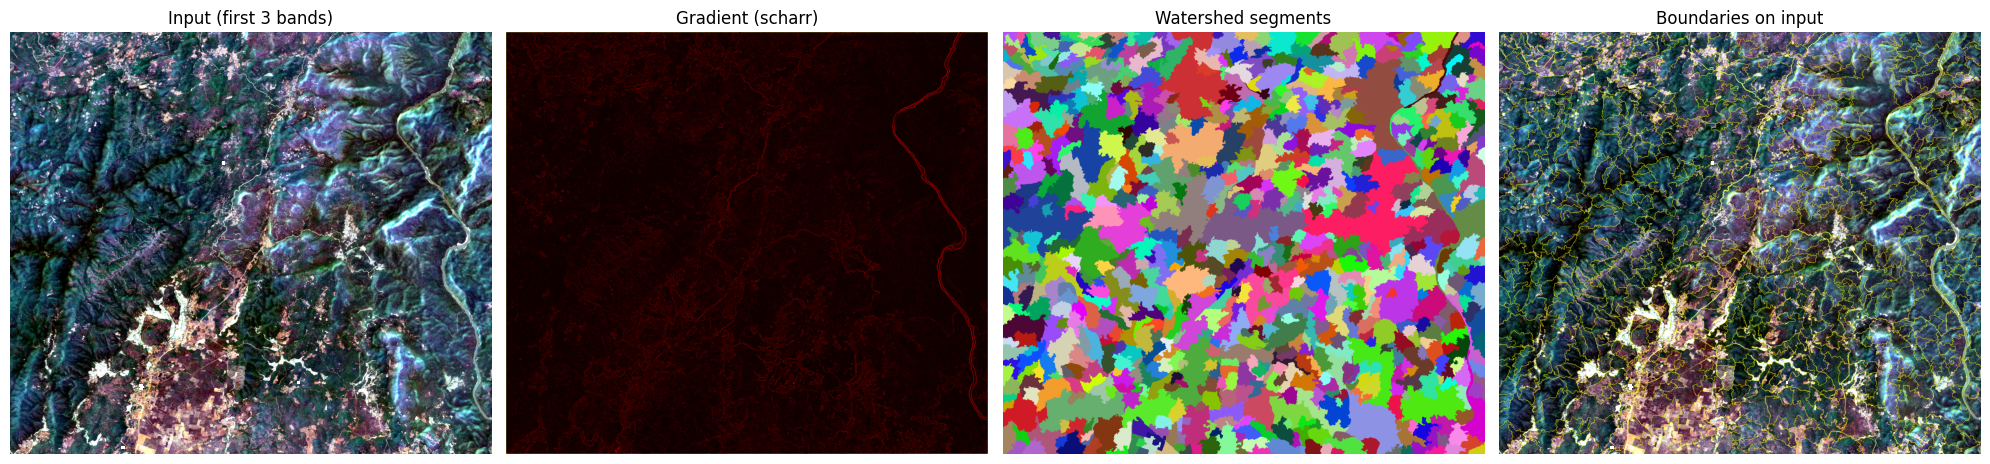

In [5]:
import matplotlib.pyplot as plt
# prep inputs for display
rgb = x[0, :3].permute(1, 2, 0).cpu().numpy()

# Per-band percentile stretch on valid (non-zero) pixels only
rgb_norm = np.zeros_like(rgb, dtype=np.float32)
for i in range(3):
    band = rgb[:, :, i]
    valid = band[band > 0]
    if valid.size > 0:
        p2, p98 = np.percentile(valid, (2, 98))
        rgb_norm[:, :, i] = np.clip((band - p2) / (p98 - p2 + 1e-8), 0, 1)
rgb = rgb_norm

grad_np   = gradient.squeeze().cpu().numpy()

# random-colour label map
rng     = np.random.default_rng(42)
palette = rng.integers(0, 255, size=(labels.max() + 1, 3), dtype=np.uint8)
coloured = palette[labels]                                 # (H, W, 3)

# segment boundaries overlaid on RGB
from skimage.segmentation import mark_boundaries
bounded = mark_boundaries(rgb, labels, color=(1, 1, 0), mode='thick')

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(rgb)
axes[0].set_title("Input (first 3 bands)")
axes[0].axis("off")

axes[1].imshow(grad_np, cmap="hot")
axes[1].set_title(f"Gradient ({model.filter_type})")
axes[1].axis("off")

axes[2].imshow(coloured)
axes[2].set_title("Watershed segments")
axes[2].axis("off")

axes[3].imshow(bounded)
axes[3].set_title("Boundaries on input")
axes[3].axis("off")

plt.tight_layout()
plt.show()


In [6]:
OUT_PATH = TIF_PATH.replace(".tif", f"_watershed_area_{MIN_AREA}.tif")

# A pixel is a boundary if it belongs to a field AND any 4-connected neighbor
# has a *different* label (whether background or a different field segment).
L = labels
is_field = L > 0

boundary_mask = np.zeros(L.shape, dtype=bool)
boundary_mask[:-1, :] |= L[:-1, :] != L[1:, :]   # compare with pixel below
boundary_mask[1:,  :] |= L[:-1, :] != L[1:, :]   # compare with pixel above
boundary_mask[:, :-1] |= L[:, :-1] != L[:, 1:]   # compare with pixel right
boundary_mask[:, 1:]  |= L[:, :-1] != L[:, 1:]   # compare with pixel left
boundary_mask &= is_field  # only keep boundary pixels that are actual fields

output = is_field.astype(np.uint8)   # 0 = background, 1 = field extent
output[boundary_mask] = 2            # 2 = field boundary

with rasterio.open(TIF_PATH) as src:
    profile = src.profile.copy()

profile.update(
    {
        "driver": "GTiff",
        "count": 1,
        "dtype": "uint8",
        "compress": "lzw",
        "predictor": 2,
        "blockxsize": 512,
        "blockysize": 512,
        "tiled": True,
        "interleave": "pixel",
        "nodata": 0,
    }
)

with rasterio.open(OUT_PATH, "w", **profile) as dst:
    dst.write(output[np.newaxis])  # (1, H, W)

print(f"Saved → {OUT_PATH}")
print(f"  unique values: {np.unique(output)}")
print(f"  0 = background/nodata  |  1 = field interior  |  2 = field boundary")


Saved → /bigdata/datasets_analytics/afghanistan_poppies/parcel_delineation/myanmar/s2_composites/myanmar_2025_watershed_area_1000.tif
  unique values: [0 1 2]
  0 = background/nodata  |  1 = field interior  |  2 = field boundary


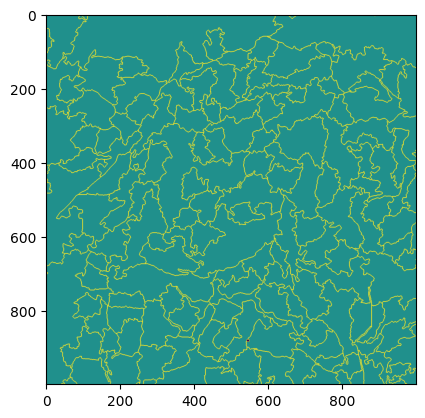

In [7]:
with rasterio.open  (OUT_PATH) as src:
    plt.imshow(src.read().transpose(1,2,0)[1000:2000, 1000:2000:])